# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [37]:

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

!pip install -q tensorflow tensorflow-model-optimization
import math
import zipfile
import random
import urllib.request
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tf_keras as keras                          # ← use tf_keras directly
from tf_keras import layers                       # ← same here

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

print("keras:", keras.__version__)         # now works
print("tfmot:", tfmot.__version__)

TensorFlow version: 2.21.0
keras: 2.19.0
tfmot: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [38]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /content/UCI HAR Dataset


## 3. Load the Data


In [39]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [40]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [41]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(1024, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 1024)              575488    
                                                                 
 dropout_11 (Dropout)        (None, 1024)              0         
                                                                 
 dense_17 (Dense)            (None, 512)               524800    
                                                                 
 dropout_12 (Dropout)        (None, 512)               0         
                                                                 
 dense_18 (Dense)            (None, 256)               131328    
                                                                 
 dropout_13 (Dropout)        (None, 256)               0         
                                                                 
 dense_19 (Dense)            (None, 6)                

## 6. Train the Teacher Model


In [42]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    #<--- Enter your code here --->#
        X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=teacher_callbacks,
    verbose=1
)


Epoch 1/50
46/46 [==============================] - 3s 53ms/step - loss: 0.7204 - accuracy: 0.6786 - val_loss: 0.2625 - val_accuracy: 0.8926
Epoch 2/50
46/46 [==============================] - 2s 47ms/step - loss: 0.2583 - accuracy: 0.8958 - val_loss: 0.2141 - val_accuracy: 0.9116
Epoch 3/50
46/46 [==============================] - 2s 49ms/step - loss: 0.2105 - accuracy: 0.9070 - val_loss: 0.3075 - val_accuracy: 0.8885
Epoch 4/50
46/46 [==============================] - 2s 47ms/step - loss: 0.1676 - accuracy: 0.9330 - val_loss: 0.1874 - val_accuracy: 0.9341
Epoch 5/50
46/46 [==============================] - 3s 57ms/step - loss: 0.1271 - accuracy: 0.9485 - val_loss: 0.1741 - val_accuracy: 0.9381
Epoch 6/50
46/46 [==============================] - 2s 51ms/step - loss: 0.1175 - accuracy: 0.9514 - val_loss: 0.1875 - val_accuracy: 0.9381
Epoch 7/50
46/46 [==============================] - 2s 51ms/step - loss: 0.1121 - accuracy: 0.9563 - val_loss: 0.1261 - val_accuracy: 0.9463
Epoch 8/50
46

### Teacher Training Curves


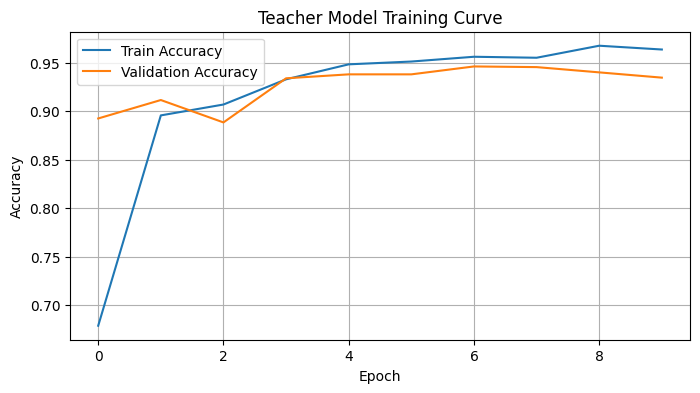

In [43]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [44]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)

Epoch 1/50
92/92 [==============================] - 1s 5ms/step - loss: 0.7453 - accuracy: 0.6953 - val_loss: 0.2939 - val_accuracy: 0.9035
Epoch 2/50
92/92 [==============================] - 0s 4ms/step - loss: 0.3154 - accuracy: 0.8738 - val_loss: 0.2008 - val_accuracy: 0.9143
Epoch 3/50
92/92 [==============================] - 0s 3ms/step - loss: 0.2268 - accuracy: 0.9092 - val_loss: 0.1837 - val_accuracy: 0.9252
Epoch 4/50
92/92 [==============================] - 0s 3ms/step - loss: 0.1824 - accuracy: 0.9259 - val_loss: 0.1449 - val_accuracy: 0.9368
Epoch 5/50
92/92 [==============================] - 0s 3ms/step - loss: 0.1516 - accuracy: 0.9396 - val_loss: 0.1682 - val_accuracy: 0.9307
Epoch 6/50
92/92 [==============================] - 0s 3ms/step - loss: 0.1195 - accuracy: 0.9537 - val_loss: 0.2059 - val_accuracy: 0.9279
Epoch 7/50
92/92 [==============================] - 0s 3ms/step - loss: 0.1130 - accuracy: 0.9580 - val_loss: 0.1532 - val_accuracy: 0.9341


## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [45]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 6ms/step - loss: 0.1510 - accuracy: 0.9384 - val_loss: 0.1416 - val_accuracy: 0.9409
Epoch 2/20
92/92 [==============================] - 0s 5ms/step - loss: 0.1222 - accuracy: 0.9539 - val_loss: 0.1331 - val_accuracy: 0.9422
Epoch 3/20
92/92 [==============================] - 0s 5ms/step - loss: 0.1048 - accuracy: 0.9628 - val_loss: 0.1400 - val_accuracy: 0.9402
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0895 - accuracy: 0.9662 - val_loss: 0.1616 - val_accuracy: 0.9381
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0858 - accuracy: 0.9668 - val_loss: 0.1565 - val_accuracy: 0.9368


## 9. Evaluate the Baseline Student Model


In [46]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)
   #<--- Enter your code here --->#

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            ) * (self.temperature ** 2)

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [47]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    #<--- Enter your code here --->#
        X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/50
46/46 [==============================] - 2s 22ms/step - accuracy: 0.5763 - student_loss: 1.0061 - distillation_loss: 0.0437 - val_accuracy: 0.8790 - val_student_loss: 0.3164
Epoch 2/50
46/46 [==============================] - 0s 10ms/step - accuracy: 0.8145 - student_loss: 0.4618 - distillation_loss: 0.0189 - val_accuracy: 0.9198 - val_student_loss: 0.0677
Epoch 3/50
46/46 [==============================] - 0s 10ms/step - accuracy: 0.8839 - student_loss: 0.3025 - distillation_loss: 0.0109 - val_accuracy: 0.9293 - val_student_loss: 0.0173
Epoch 4/50
46/46 [==============================] - 0s 10ms/step - accuracy: 0.9203 - student_loss: 0.2176 - distillation_loss: 0.0066 - val_accuracy: 0.9334 - val_student_loss: 0.0076
Epoch 5/50
46/46 [==============================] - 1s 11ms/step - accuracy: 0.9296 - student_loss: 0.1814 - distillation_loss: 0.0052 - val_accuracy: 0.9381 - val_student_loss: 0.0054
Epoch 6/50
46/46 [==============================] - 0s 10ms/step - accuracy

## 11. Train the Distilled Student


In [48]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 8ms/step - accuracy: 0.6451 - student_loss: 0.8233 - distillation_loss: 0.0364 - val_accuracy: 0.8865 - val_student_loss: 0.1039
Epoch 2/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.8592 - student_loss: 0.3415 - distillation_loss: 0.0133 - val_accuracy: 0.9177 - val_student_loss: 0.0161
Epoch 3/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9039 - student_loss: 0.2421 - distillation_loss: 0.0082 - val_accuracy: 0.9341 - val_student_loss: 0.0053
Epoch 4/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9303 - student_loss: 0.1724 - distillation_loss: 0.0047 - val_accuracy: 0.9286 - val_student_loss: 0.0043
Epoch 5/20
92/92 [==============================] - 1s 11ms/step - accuracy: 0.9422 - student_loss: 0.1494 - distillation_loss: 0.0040 - val_accuracy: 0.9354 - val_student_loss: 0.0010
Epoch 6/20
92/92 [==============================] - 1s 9ms/step - accuracy: 0.9

### Distillation Training Curves


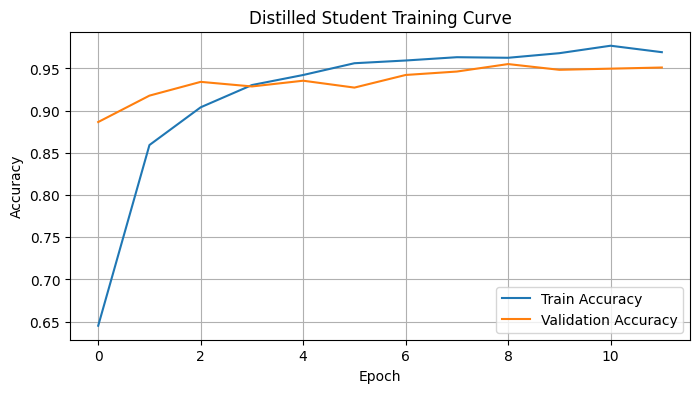

In [49]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9423

                    precision    recall  f1-score   support

           WALKING     0.9756    0.9677    0.9717       496
  WALKING_UPSTAIRS     0.9027    0.9851    0.9421       471
WALKING_DOWNSTAIRS     0.9635    0.8810    0.9204       420
           SITTING     0.9365    0.8717    0.9030       491
          STANDING     0.8856    0.9455    0.9145       532
            LAYING     1.0000    0.9907    0.9953       537

          accuracy                         0.9423      2947
         macro avg     0.9440    0.9403    0.9412      2947
      weighted avg     0.9439    0.9423    0.9422      2947



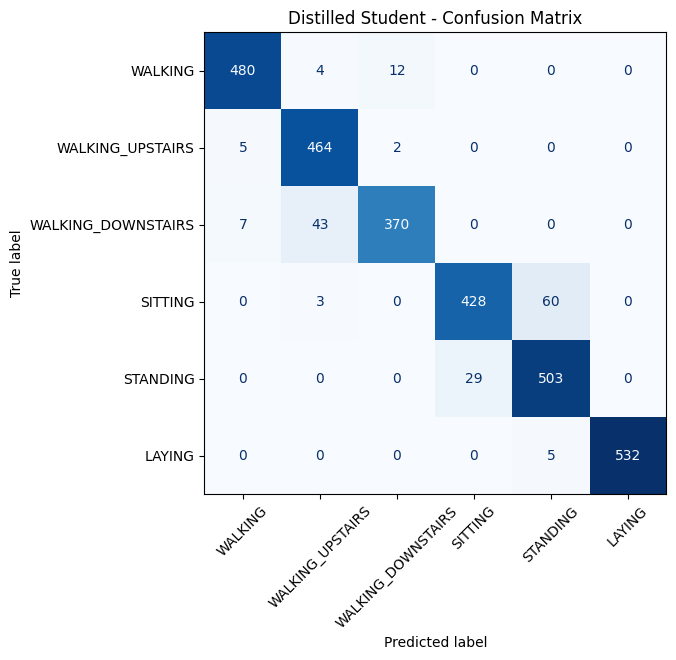

In [50]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [51]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = (x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = (x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output =            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [52]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [53]:
from tensorflow_model_optimization.python.core.sparsity.keras import prunable_layer
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)


pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.

student_for_pruning = tf.keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1

pruned__history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/10
92/92 [==============================] - 2s 6ms/step - loss: 0.0961 - accuracy: 0.9614 - val_loss: 0.1385 - val_accuracy: 0.9470
Epoch 2/10
92/92 [==============================] - 0s 4ms/step - loss: 0.0823 - accuracy: 0.9682 - val_loss: 0.1279 - val_accuracy: 0.9511
Epoch 3/10
92/92 [==============================] - 0s 4ms/step - loss: 0.0760 - accuracy: 0.9725 - val_loss: 0.1262 - val_accuracy: 0.9538
Epoch 4/10
92/92 [==============================] - 0s 5ms/step - loss: 0.0836 - accuracy: 0.9725 - val_loss: 0.1004 - val_accuracy: 0.9531
Epoch 5/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1665 - accuracy: 0.9396 - val_loss: 0.1172 - val_accuracy: 0.9511
Epoch 6/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1739 - accuracy: 0.9366 - val_loss: 0.1449 - val_accuracy: 0.9436


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [54]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = tf.lite.TFLiteConverter.from_keras_model(pruned_distilled_model).convert()
#<--- Enter your code here --->#
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)
 #<--- Enter your code here --->#

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Pruned distilled model with mask accuracy: 0.9274
Pruned distilled model with mask size (KB): 634.72
Stripped sparse distilled model accuracy: 0.9274
Stripped sparse distilled model size (KB): 217.85


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [55]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
def representative_dataset():
    for i in range(100):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8

converter.inference_output_type = tf.int8
stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


Stripped Sparse + INT8 Accuracy: 0.9274
Stripped Sparse + INT8 Size (KB): 86.35


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [56]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


Stripped Sparse + INT8 Accuracy: 0.9281
Stripped Sparse + INT8 Size (KB): 116.52


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [61]:
distilled_fp32_tflite = tf.lite.TFLiteConverter.from_keras_model(distilled_student).convert()

distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.942314,316.906250
1,Pruned Distilled TFLite (with mask),FP32,0.927384,634.722656
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.927384,217.847656
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.928062,116.515625


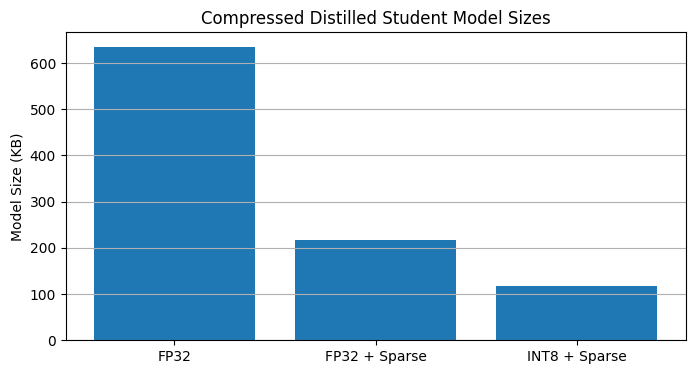

In [62]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


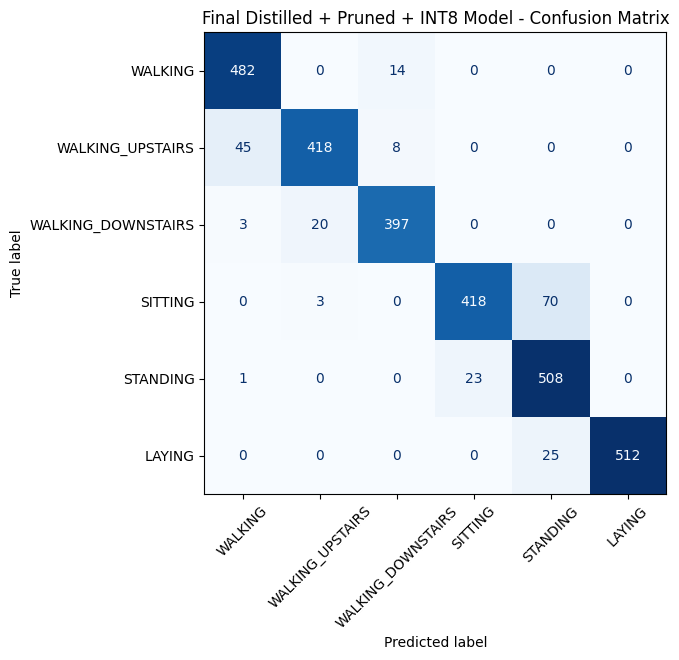

In [63]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?

The baseline student sets the normal floor being trained with hard labels. The distilled student by learning from the teacher's soft labels captures more nuanced information about the teacher's internal logic, allowing it to generalize better than a baseline model.

2. Did **knowledge distillation** help the smaller model retain performance?

Yes, knowledge distillation is  effective at helping smaller models retain performance. By acting as a form of regularization, the teacher's soft labels guide the student to learn better representations than  hard labels would allow.

3. What happened to the model size after **pruning** and after **INT8 quantization**?

After pruning, the model was the largest because the mask tensors  were stored alongside the weights

After the INT8 quantization the size went down  by converting 32-bit floating-point weights into 8-bit integers.

4. Which model would you choose for **Arduino deployment**, and why?

I would choose the Stripped Sparse INT8 model. It is the smallest version, which fits  the limited  memory of an Arduino. Furthermore, the INT8 format allows the microcontroller to use more  integer-only arithmetic, which is  faster and more energy-efficient than floating-point math.

5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?
Its small size ensures it fits in constrained memory and the INT8 operations allow the microcontroller to process data quickly with low power consumption, enabling real-time edge decisions and the performance is much better


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
